In [1]:
import numpy as np
from pythtb import TBModel, WFArray, Mesh, Lattice
from pythtb.models.haldane import haldane

import matplotlib.pyplot as plt

In [2]:
# tight-binding parameters
delta = 1
t = 1
t2 = -0.3

model = haldane(delta, t, t2)
print(model) 

----------------------------------------
       Tight-binding model report       
----------------------------------------
r-space dimension           = 2
k-space dimension           = 2
periodic directions         = [0, 1]
number of orbitals          = 2
number of spin components   = 1
number of electronic states = 2

Lattice vectors (Cartesian):
  # 0 ===> [ 1.000,  0.000]
  # 1 ===> [ 0.500,  0.866]
Volume of unit cell (Cartesian) = 0.866 [A^d]

Reciprocal lattice vectors (Cartesian):
  # 0 ===> [ 6.283, -3.628]
  # 1 ===> [ 0.000,  7.255]
Volume of reciprocal unit cell = 45.586 [A^-d]

Orbital vectors (Cartesian):
  # 0 ===> [ 0.500,  0.289]
  # 1 ===> [ 1.000,  0.577]
Orbital vectors (fractional):
  # 0 ===> [ 0.333,  0.333]
  # 1 ===> [ 0.667,  0.667]
No symmetry operations registered.

----------------------------------------
Site energies:
  # 0 ===> -1.000 
  # 1 ===>  1.000 
Hoppings:
  < 0 | H | 1 + [ 0.0 ,  0.0 ] >  ===> 1.0000 
  < 0 | H | 1 + [-1.0 ,  0.0 ] >  ===> 1.0000

(<Figure size 640x480 with 2 Axes>, <Axes: ylabel='Energy $E(\\mathbf{{k}})$'>)

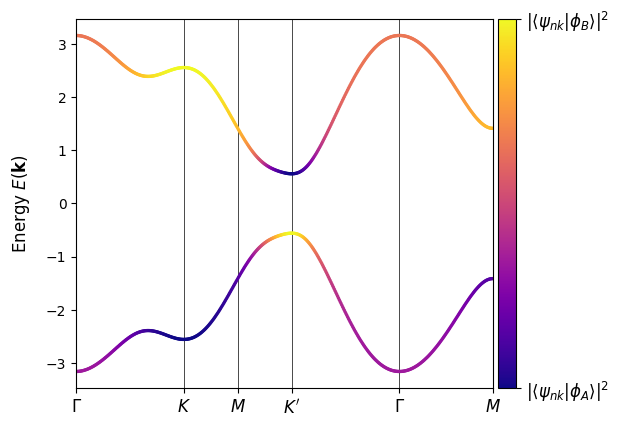

In [3]:
k_path = [[0, 0], [2/3, 1/3], [.5, .5], [1/3, 2/3], [0, 0], [.5, .5]]
k_label = (r'$\Gamma $',r'$K$', r'$M$', r'$K^\prime$', r'$\Gamma $', r'$M$')
(k_vec, k_dist, k_node) = model.k_path(k_path, 101, report=False)

model.plot_bands(k_path, k_label=k_label, nk=501, scat_size=2, proj_orb_idx=[1], cmap='plasma')

In [4]:
mesh = Mesh(dim_k=2, axis_types=['k', 'k'])
mesh.build_grid(shape=(20, 20))
print(mesh)

Mesh Summary
Type: grid
Dimensionality: 2 k-dim(s) + 0 λ-dim(s)
Number of mesh points: 400
Full shape: (20, 20, 2)
k-axes: [Axis(type=k, name=k_0, size=20), Axis(type=k, name=k_1, size=20)]
λ-axes: []
Is a torus in k-space (all k-axes wind BZ): yes
Looped axes: (axis 0 loops component 0), (axis 1 loops component 1)
Endpoint axes: None
BZ-winding axes: (axis 0 winds component 0), (axis 1 winds component 1)


In [5]:
wfa = WFArray(model, mesh)
wfa.solve_mesh()

In [6]:
bflux = wfa.berry_flux(state_idx=[0], plane=(0,1))

In [7]:
chern = wfa.chern_num(state_idx=[0], plane=(0,1))
print(f"Chern # occupied: {chern.real: .1f}")

Chern # occupied:  1.0


In [8]:
mesh_cart = mesh.grid @ model.recip_lat_vecs
KX, KY= mesh_cart[..., 0], mesh_cart[..., 1]

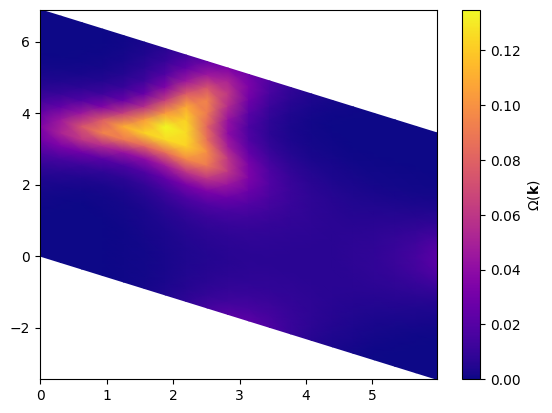

In [9]:
im = plt.pcolormesh(KX, KY, bflux, cmap='plasma', shading='gouraud')
plt.colorbar(label=r'$\Omega(\mathbf{k})$')

In [10]:
kpts = mesh.flat

In [11]:
bflux_kubo = model.berry_curvature(kpts, occ_idxs=[0])[0, 1].reshape(mesh.shape_k)

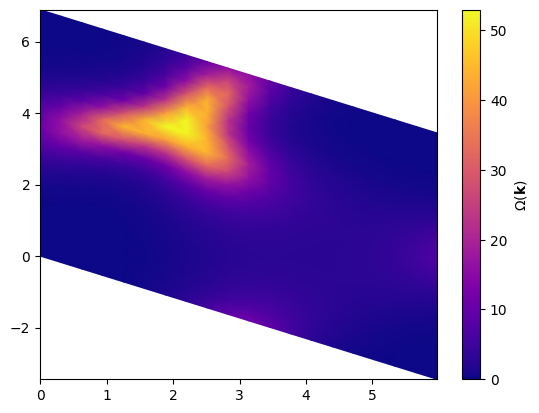

In [12]:
im = plt.pcolormesh(KX, KY, bflux_kubo.real, cmap='plasma', shading='gouraud')
plt.colorbar(label=r'$\Omega(\mathbf{k})$')